In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from transformers import ViTForImageClassification, ViTImageProcessor
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
import torch

Introduction : After testing a multi-class classification in project 6 using a CNN, we will try in this notebook a new recent method, ViT, which takes the fundamentals of transformers used in NLP and applies them to image classification.

**Chapter 1** : Personal technical notes about ViT. Official Google Research paper : https://www.academia.edu/95250851/An_Image_is_Worth_16x16_Words_Transformers_for_Image_Recognition_at_Scale#:~:text=Houlsby%2C%20N.%20%282021%29%20%E2%80%9CAn%20Image%20is%20Worth%2016x16,tasks%2C%20its%20applications%20to%20computer%20vision%20remain%20limited.

**Chapter 2** : Experimentation on a test small dataset (72 images and 3 categories) to understand to required formatting

**Chapter 3** : Experimentation on train_test_split and useful metrics

**Chapter 4** : ViT model run on the project 6 Flipkart dataset (1050 images database and 7 categories).

**Chapter 5** : Improve the model using data augmentation

**Chapter 6** : Compare results

# What is ViT ?

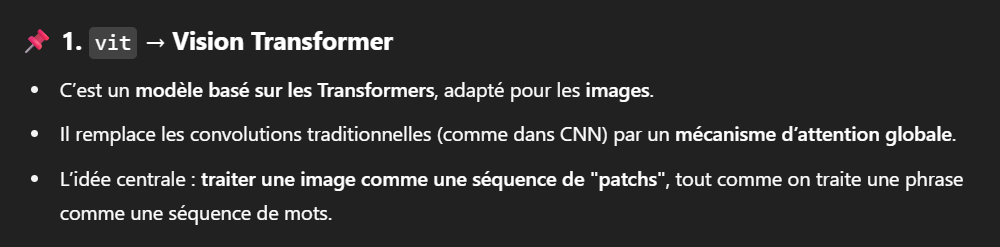

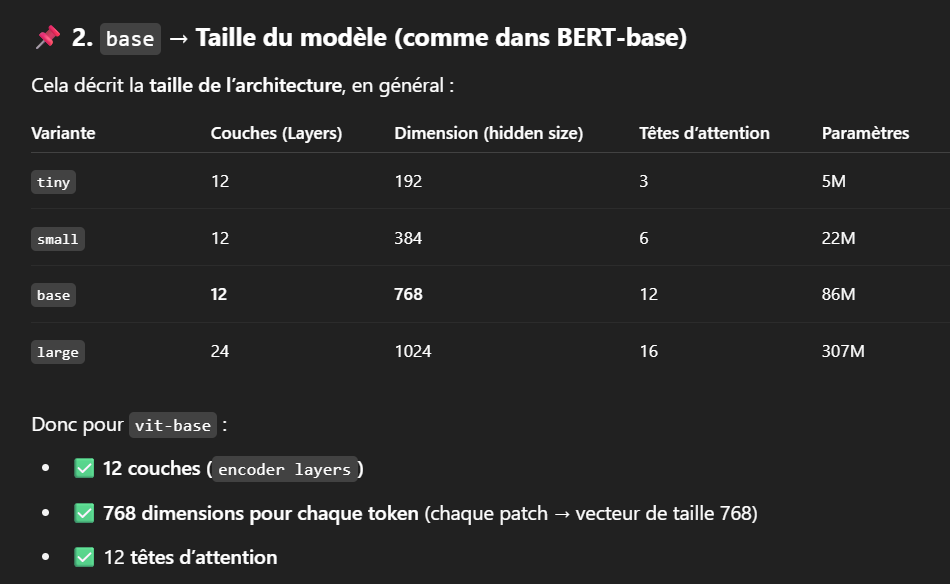

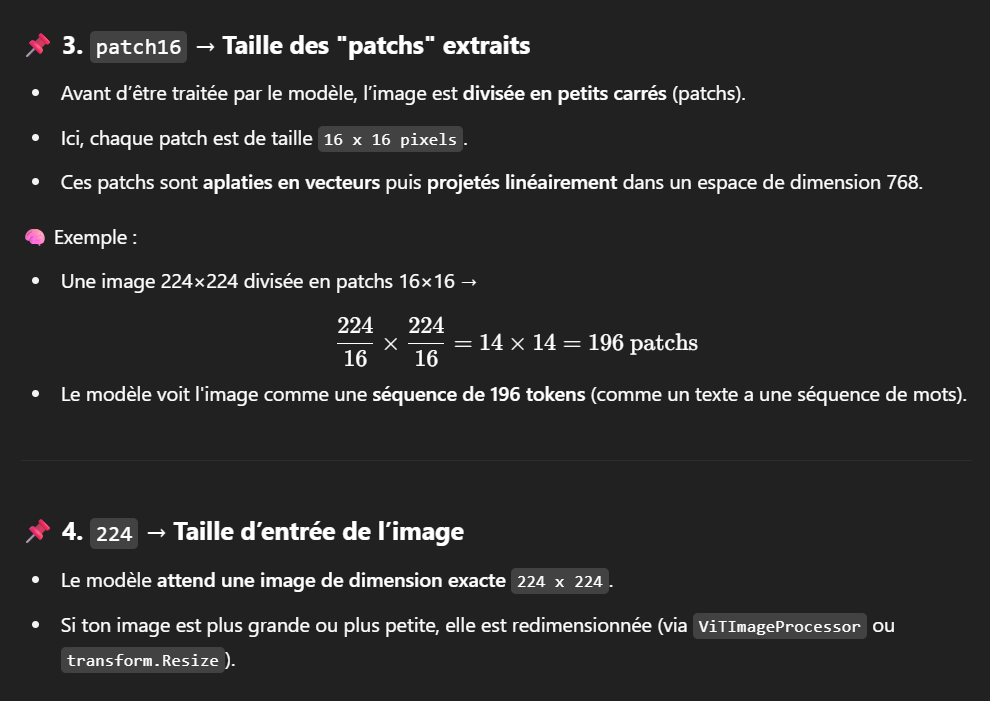

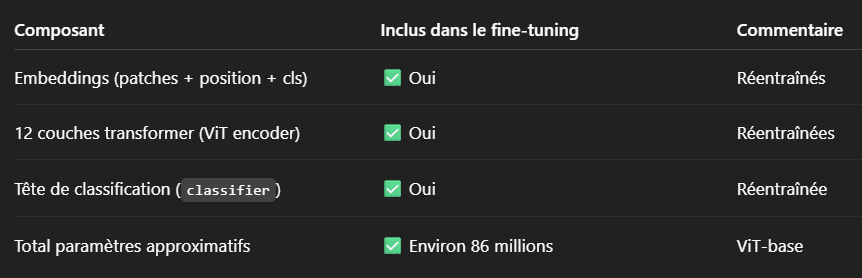

# Work on test dataset

The dataset must be organized according to the following structure :

dataset /

        categorie1 / (images)

        categorie2 / (images)

        ...

In [25]:
# Path to the dataset ("dataset" is a small dataset used for test prupose only)
dataset_path = "dataset"

# Classes
classes = sorted(os.listdir(dataset_path))
num_classes = len(classes)

print(f'The dataset has {num_classes} categories : {classes}')

The dataset has 3 categories : ['categorie1', 'categorie2', 'categorie3']


In [27]:
# Images preprocessing
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

In [29]:
# Custom Dataset
class CustomDataset(Dataset):
    def __init__(self, dataset_path, processor, transform=None):
        self.dataset_path = dataset_path
        self.processor = processor
        self.transform = transform
        self.classes = sorted(os.listdir(dataset_path))
        self.images = []
        self.labels = []
        for label, class_name in enumerate(self.classes):
            class_path = os.path.join(dataset_path, class_name)
            for image_name in os.listdir(class_path):
                self.images.append(os.path.join(class_path, image_name))
                self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        encoding = self.processor(images=image, return_tensors="pt")
        encoding['pixel_values'] = encoding['pixel_values'].squeeze(0)
        encoding['labels'] = torch.tensor(self.labels[idx])
        return encoding

In [31]:
### TEST ###
dataset = CustomDataset(dataset_path=dataset_path, processor=processor, transform=None)
sample = dataset[5]

# Display keys and types
print(f"Dictionnary keys : {sample.keys()}")
for k, v in sample.items():
    print(f"{k}: type={type(v)}, shape={(v.shape if torch.is_tensor(v) else 'N/A')}")

# Display the number of pictures in the dataset
print(f'There are {len(dataset)} pictures in the dataset')

Dictionnary keys : dict_keys(['pixel_values', 'labels'])
pixel_values: type=<class 'torch.Tensor'>, shape=torch.Size([3, 224, 224])
labels: type=<class 'torch.Tensor'>, shape=torch.Size([])
There are 72 pictures in the dataset


In [33]:
sample

{'pixel_values': tensor([[[0.8824, 0.8902, 0.8824,  ..., 0.9608, 0.9608, 0.9608],
         [0.8824, 0.8824, 0.8824,  ..., 0.9451, 0.9529, 0.9529],
         [0.8902, 0.8824, 0.8824,  ..., 0.9294, 0.9373, 0.9373],
         ...,
         [0.9529, 0.9686, 0.9608,  ..., 0.9922, 0.9922, 1.0000],
         [0.9686, 0.9608, 0.9529,  ..., 0.9922, 0.9922, 1.0000],
         [0.9843, 0.9608, 0.9765,  ..., 0.9922, 0.9922, 1.0000]],

        [[0.8196, 0.8196, 0.8118,  ..., 0.9216, 0.9216, 0.9216],
         [0.8196, 0.8118, 0.8118,  ..., 0.9059, 0.9137, 0.9137],
         [0.8275, 0.8118, 0.8118,  ..., 0.8902, 0.8980, 0.8980],
         ...,
         [0.9373, 0.9529, 0.9451,  ..., 0.9843, 0.9765, 0.9922],
         [0.9529, 0.9451, 0.9373,  ..., 0.9843, 0.9765, 0.9922],
         [0.9686, 0.9451, 0.9608,  ..., 0.9843, 0.9765, 0.9922]],

        [[0.8118, 0.8196, 0.8196,  ..., 0.8902, 0.8902, 0.8902],
         [0.8039, 0.8118, 0.8196,  ..., 0.8745, 0.8824, 0.8824],
         [0.8118, 0.8118, 0.8196,  ..., 0

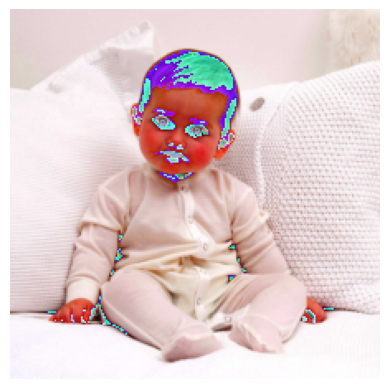

In [37]:
### TEST ###
# Display the sample picture
pixel_values = sample['pixel_values']

# Convert tensor to numpy reshaped (224, 224, 3)
image_np = pixel_values.permute(1, 2, 0).numpy()

# Denormalize pciture (0-1 to 0-255)
if image_np.max() <= 1.0:
    image_np = (image_np * 255).astype(np.uint8)

# Display picture
plt.imshow(image_np)
plt.axis('off')
plt.show()

In [39]:
# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
])
# rem : no need to transforms.ToTensor()

In [41]:
### TEST ###
dataset = CustomDataset(dataset_path=dataset_path, processor=processor, transform=transform)
sample = dataset[0]
print(f"pixel_values shape: {sample['pixel_values'].shape}")
print(f"labels shape: {sample['labels'].shape}")

pixel_values shape: torch.Size([3, 224, 224])
labels shape: torch.Size([])


In [43]:
# Create dataset and dataloader
dataset = CustomDataset(dataset_path, processor, transform=transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [45]:
### TEST ###
# Get the first batch of data from the dataloader
batch = next(iter(dataloader))

# Check keys and values type
print(f"Batch keys : {batch.keys()}")
for k, v in batch.items():
    print(f"{k}: type={type(v)}, shape={v.shape}")

Batch keys : dict_keys(['pixel_values', 'labels'])
pixel_values: type=<class 'torch.Tensor'>, shape=torch.Size([8, 3, 224, 224])
labels: type=<class 'torch.Tensor'>, shape=torch.Size([8])


In [47]:
# Load the pre-trained ViT model without the classification layer (1000 vs 3)
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    id2label={str(i): c for i, c in enumerate(classes)},
    label2id={c: i for i, c in enumerate(classes)}
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


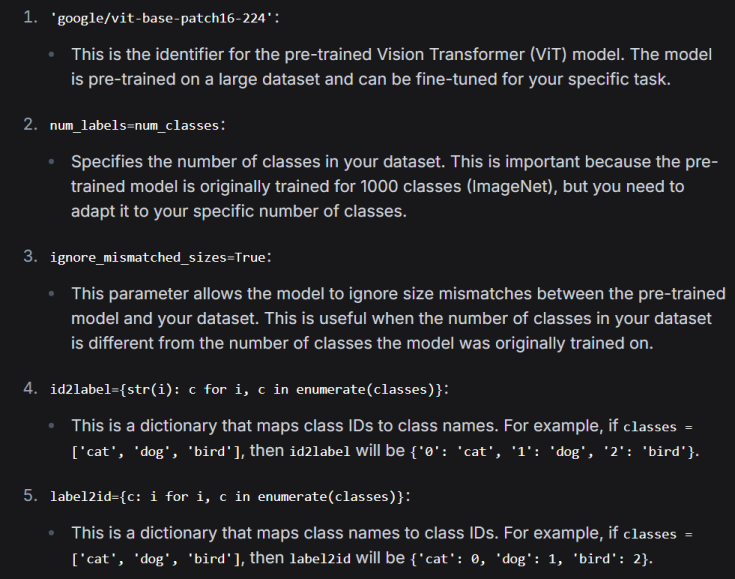

In [50]:
### TEST ###
print(model.config.num_labels)
print(model.config.id2label)
print(model.config.label2id)
print(model.classifier.out_features)

3
{'0': 'categorie1', '1': 'categorie2', '2': 'categorie3'}
{'categorie1': 0, 'categorie2': 1, 'categorie3': 2}
3


In [52]:
### TEST ###
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(next(model.parameters()).device)    # must be 'cuda:0' or 'cpu'

cpu


rem : PyTorch's CUDA support is specifically designed for NVIDIA GPUs. Unfortunately AMD GPUs are not recognized.

In [55]:
### TEST ###
# Test to verify that the model is working correctly with a batch from dataloader
# Understand the shape of the output logits
batch = next(iter(dataloader))

# Send to the correct device (CPU in my case)
inputs = {k: v.to(device) for k, v in batch.items()}

# Passes the input data through the model without gradient calculation (for test)

with torch.no_grad():
    outputs = model(**inputs)

# Display the shape of the output
print("Logits shape :", outputs.logits.shape)

# rem : The logits are the raw output scores from the model before applying any activation function
# (like softmax)

# Visualize output logits
outputs.logits

Logits shape : torch.Size([8, 3])


tensor([[ 0.4404, -0.3646, -0.9052],
        [-0.8127,  0.2208,  0.4462],
        [-1.2125,  0.2342,  0.2933],
        [ 0.3493, -0.0800, -1.6013],
        [ 0.7681,  0.0509,  0.7043],
        [-0.1688,  0.7984, -1.2901],
        [-0.0803,  0.4559, -0.3962],
        [ 0.1347,  0.3699,  0.4680]])

In [57]:
# Reconstruire la couche de classification
#model.classifier = torch.nn.Linear(model.config.hidden_size, num_classes)

In [59]:
# Move the model to the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

In [61]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

In [63]:
# Training loop
for epoch in range(5):  # Number of epoch
    epoch_start_time = time.time()  # Start time for the epoch
    
    for batch in dataloader:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        # Pass the input pixel values and labels through the model
        outputs = model(pixel_values=pixel_values, labels=labels)
        # Extracts the loss value from the outputs
        loss = outputs.loss
        # Computes the gradients of the loss
        loss.backward()
        # Updates the model's parameters based on the computed gradients
        optimizer.step()
        # Resets the gradients to zero
        optimizer.zero_grad()

    epoch_end_time = time.time()  # End time for the epoch
    epoch_processing_time = epoch_end_time - epoch_start_time
    print(f"Epoch {epoch + 1} processing time: {epoch_processing_time:.4f} seconds")   

Epoch 1 processing time: 27.2341 seconds
Epoch 2 processing time: 27.5525 seconds
Epoch 3 processing time: 26.7964 seconds
Epoch 4 processing time: 26.4944 seconds
Epoch 5 processing time: 26.8986 seconds


In [64]:
# Sauvegarde du modèle
model.save_pretrained("fined_tuned_demo_VIT_model")

# Add train_test_split and performance measures

In [64]:
# Create dataset and dataloader
dataset = CustomDataset(dataset_path, processor, transform=transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# Load the pre-trained ViT model without the classification layer (1000 vs 3)
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    id2label={str(i): c for i, c in enumerate(classes)},
    label2id={c: i for i, c in enumerate(classes)}
)

# Move the model to the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

In [82]:
# Split train/validation (stratified by labels)
all_indices = list(range(len(dataset)))
train_indices, val_indices = train_test_split(all_indices, test_size=0.3, stratify=dataset.labels, random_state=88)

# Create subsets from the indices
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [84]:
# Verify train and val dataset dimension
len(train_dataset), len(val_dataset)

(50, 22)

In [86]:
# Main training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

for epoch in range(5):
    epoch_start_time = time.time()  # Start time for the epoch
    model.train()
    total_loss = 0

    for batch in train_loader:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    

    # --- Evaluation on the validation set ---
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(pixel_values=pixel_values)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = correct / total

    epoch_end_time = time.time()  # End time for the epoch
    epoch_processing_time = epoch_end_time - epoch_start_time
    print(f"Epoch {epoch + 1} - Processing time: {epoch_processing_time:.4f} seconds")
    print(f"Epoch {epoch+1} - Train Loss: {avg_loss:.4f}")
    print(f"Epoch {epoch+1} - Val Accuracy: {accuracy:.2%}")
    print(f"Epoch {epoch+1} - Classification report : \n", classification_report(all_labels, all_preds, target_names=classes))
    print()

Epoch 1 - Processing time: 24.3591 seconds
Epoch 1 - Train Loss: 0.7198
Epoch 1 - Val Accuracy: 81.82%
Epoch 1 - Classification report : 
               precision    recall  f1-score   support

  categorie1       0.67      1.00      0.80         8
  categorie2       1.00      0.71      0.83         7
  categorie3       1.00      0.71      0.83         7

    accuracy                           0.82        22
   macro avg       0.89      0.81      0.82        22
weighted avg       0.88      0.82      0.82        22


Epoch 2 - Processing time: 23.9763 seconds
Epoch 2 - Train Loss: 0.3628
Epoch 2 - Val Accuracy: 77.27%
Epoch 2 - Classification report : 
               precision    recall  f1-score   support

  categorie1       0.67      1.00      0.80         8
  categorie2       1.00      0.71      0.83         7
  categorie3       0.80      0.57      0.67         7

    accuracy                           0.77        22
   macro avg       0.82      0.76      0.77        22
weighted avg  

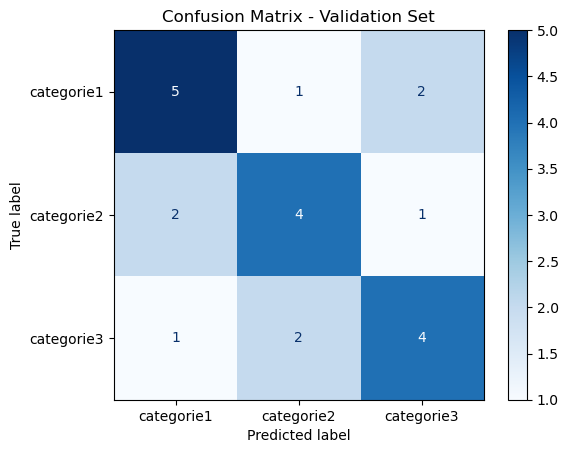

In [72]:
# Confusion matrix

# Evaluation mode
model.eval()

# Collect predictions and labels
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(pixel_values=pixel_values)
        preds = outputs.logits.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Build confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Validation Set")
plt.show()

# Train ViT model on Flipkart images

In [111]:
# Path to the dataset
dataset_path = "dataset_VIT"

# Classes
classes = sorted(os.listdir(dataset_path))
num_classes = len(classes)

print(f'The dataset has {num_classes} categories : {classes}')

The dataset has 7 categories : ['Baby Care', 'Beauty and Personal Care', 'Computers', 'Home Decor & Festive Needs', 'Home Furnishing', 'Kitchen & Dining', 'Watches']


In [113]:
# Images preprocessing
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

In [114]:
# Custom Dataset
class CustomDataset(Dataset):
    def __init__(self, dataset_path, processor, transform=None):
        self.dataset_path = dataset_path
        self.processor = processor
        self.transform = transform
        self.classes = sorted(os.listdir(dataset_path))
        self.images = []
        self.labels = []
        for label, class_name in enumerate(self.classes):
            class_path = os.path.join(dataset_path, class_name)
            for image_name in os.listdir(class_path):
                self.images.append(os.path.join(class_path, image_name))
                self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        encoding = self.processor(images=image, return_tensors="pt")
        encoding['pixel_values'] = encoding['pixel_values'].squeeze(0)
        encoding['labels'] = torch.tensor(self.labels[idx])
        return encoding

In [117]:
# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

# Create dataset
dataset = CustomDataset(dataset_path, processor, transform=transform)
#dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Load the pre-trained ViT model without the classification layer (1000 vs 3)
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    id2label={str(i): c for i, c in enumerate(classes)},
    label2id={c: i for i, c in enumerate(classes)}
)

# Move the model to the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([7, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

In [75]:
# Split train/validation (stratified by labels)
all_indices = list(range(len(dataset)))
train_indices, val_indices = train_test_split(all_indices, test_size=0.3, stratify=dataset.labels, random_state=88)

# Create subsets from the indices
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [77]:
# Main training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5) # try 1e-5 ; 5e-5

for epoch in range(6):
    epoch_start_time = time.time()  # Start time for the epoch
    model.train()
    total_loss = 0
    correct_train, total_train = 0, 0

    for batch in train_loader:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()

        # --- Train accuracy ---
        preds = outputs.logits.argmax(dim=-1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    avg_loss = total_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    # --- Evaluation on the validation set ---
    model.eval()
    correct_val, total_val = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(pixel_values=pixel_values)

            # --- Validation accuracy and loss ---
            preds = outputs.logits.argmax(dim=-1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_accuracy = correct_val / total_val

    epoch_end_time = time.time()  # End time for the epoch
    epoch_processing_time = epoch_end_time - epoch_start_time
    print(f"Epoch {epoch+1} - Processing time: {epoch_processing_time:.4f} seconds")
    print(f"Epoch {epoch+1} - Train Loss: {avg_loss:.4f}")
    print(f"Epoch {epoch+1} - Train Accuracy: {train_accuracy:.2%}")
    print(f"Epoch {epoch+1} - Val Accuracy: {val_accuracy:.2%}")
    #print(f"Epoch {epoch+1} - Classification report : \n", classification_report(all_labels, all_preds, target_names=classes))
    print()

C:\Users\OmenH\anaconda3\Lib\site-packages\PIL\Image.py:3186: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 1 - Processing time: 298.2556 seconds
Epoch 1 - Train Loss: 1.7371
Epoch 1 - Train Accuracy: 36.46%
Epoch 1 - Val Accuracy: 55.56%

Epoch 2 - Processing time: 295.5416 seconds
Epoch 2 - Train Loss: 1.1875
Epoch 2 - Train Accuracy: 74.69%
Epoch 2 - Val Accuracy: 74.92%

Epoch 3 - Processing time: 294.1939 seconds
Epoch 3 - Train Loss: 0.8297
Epoch 3 - Train Accuracy: 90.34%
Epoch 3 - Val Accuracy: 82.22%

Epoch 4 - Processing time: 295.4892 seconds
Epoch 4 - Train Loss: 0.5972
Epoch 4 - Train Accuracy: 93.74%
Epoch 4 - Val Accuracy: 85.08%

Epoch 5 - Processing time: 295.4223 seconds
Epoch 5 - Train Loss: 0.4426
Epoch 5 - Train Accuracy: 95.78%
Epoch 5 - Val Accuracy: 86.03%

Epoch 6 - Processing time: 298.6230 seconds
Epoch 6 - Train Loss: 0.3340
Epoch 6 - Train Accuracy: 97.28%
Epoch 6 - Val Accuracy: 87.94%



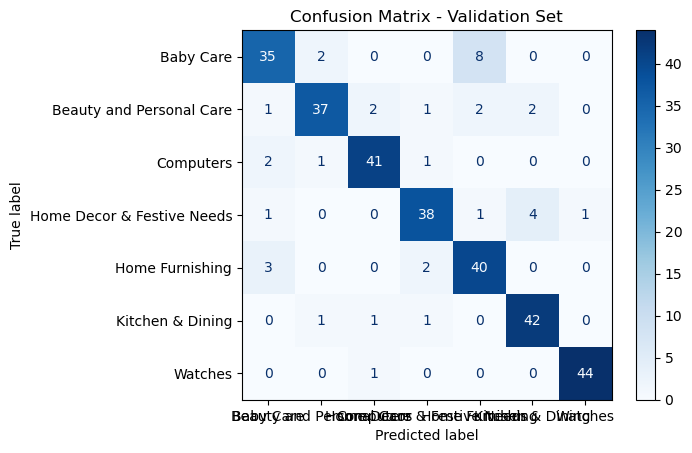

In [79]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Validation Set")
plt.show()

ccl : The ViT method works well on the Flipkart dataset. Adjusting the learning rate helps the model to converge nicely. The confusion matrix on the validation set show interestinf performances. However there is a clear remaining overfitting.

In [84]:
# How many parameters have been trained ?
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params: 85,804,039
Trainable params: 85,804,039


In [86]:
# Save model
model.save_pretrained("fined_tuned_flipkart_VIT_model")

# Improved model

To overcome the overfitting, we're going to try Data Augmentation, in order to simulate a wider image database. I laso would like to try to add a scheduler in order to automatically decrease the learning rate when the validation stagnates.

In [18]:
# Path to the dataset
dataset_path = "dataset_VIT"

# Classes
classes = sorted(os.listdir(dataset_path))
num_classes = len(classes)

print(f'The dataset has {num_classes} categories : {classes}')

The dataset has 7 categories : ['Baby Care', 'Beauty and Personal Care', 'Computers', 'Home Decor & Festive Needs', 'Home Furnishing', 'Kitchen & Dining', 'Watches']


In [21]:
# Transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

# Images preprocessing
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

In [23]:
class CustomDataset2(Dataset):
    def __init__(self, images, labels, processor, transform=None):
        self.images = images
        self.labels = labels
        self.processor = processor
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        encoding = self.processor(images=image, return_tensors="pt")
        encoding['pixel_values'] = encoding['pixel_values'].squeeze(0)
        encoding['labels'] = torch.tensor(self.labels[idx])
        return encoding


In [25]:
# Prepare path to images and labels
image_paths = []
image_labels = []

for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for fname in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, fname))
        image_labels.append(label)

In [27]:
# Train validation split
train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    image_paths, image_labels, test_size=0.3, stratify=image_labels, random_state=42
)

# Create datasets
train_dataset = CustomDataset2(train_imgs, train_labels, processor, transform=train_transform)
val_dataset = CustomDataset2(val_imgs, val_labels, processor, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load pre-trained ViT model
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    id2label={str(i): c for i, c in enumerate(classes)},
    label2id={c: i for i, c in enumerate(classes)}
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([7, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

In [29]:
# Main training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5) # try 1e-5 ; 5e-5

for epoch in range(8):
    epoch_start_time = time.time()  # Start time for the epoch
    model.train()
    total_loss = 0
    correct_train, total_train = 0, 0

    for batch in train_loader:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()

        # --- Train accuracy ---
        preds = outputs.logits.argmax(dim=-1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    avg_loss = total_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    # --- Evaluation on the validation set ---
    model.eval()
    correct_val, total_val = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(pixel_values=pixel_values)

            # --- Validation accuracy and loss ---
            preds = outputs.logits.argmax(dim=-1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_accuracy = correct_val / total_val

    epoch_end_time = time.time()  # End time for the epoch
    epoch_processing_time = epoch_end_time - epoch_start_time
    print(f"Epoch {epoch+1} - Processing time: {epoch_processing_time:.4f} seconds")
    print(f"Epoch {epoch+1} - Train Loss: {avg_loss:.4f}")
    print(f"Epoch {epoch+1} - Train Accuracy: {train_accuracy:.2%}")
    print(f"Epoch {epoch+1} - Val Accuracy: {val_accuracy:.2%}")
    #print(f"Epoch {epoch+1} - Classification report : \n", classification_report(all_labels, all_preds, target_names=classes))
    print()

C:\Users\OmenH\anaconda3\Lib\site-packages\PIL\Image.py:3186: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 1 - Processing time: 298.2753 seconds
Epoch 1 - Train Loss: 1.8247
Epoch 1 - Train Accuracy: 32.65%
Epoch 1 - Val Accuracy: 45.71%

Epoch 2 - Processing time: 296.4798 seconds
Epoch 2 - Train Loss: 1.3657
Epoch 2 - Train Accuracy: 68.71%
Epoch 2 - Val Accuracy: 67.30%

Epoch 3 - Processing time: 296.1056 seconds
Epoch 3 - Train Loss: 1.0257
Epoch 3 - Train Accuracy: 83.27%
Epoch 3 - Val Accuracy: 76.19%

Epoch 4 - Processing time: 1013.8584 seconds
Epoch 4 - Train Loss: 0.7766
Epoch 4 - Train Accuracy: 87.35%
Epoch 4 - Val Accuracy: 80.00%

Epoch 5 - Processing time: 295.6856 seconds
Epoch 5 - Train Loss: 0.6126
Epoch 5 - Train Accuracy: 91.84%
Epoch 5 - Val Accuracy: 82.86%

Epoch 6 - Processing time: 296.7519 seconds
Epoch 6 - Train Loss: 0.4903
Epoch 6 - Train Accuracy: 92.65%
Epoch 6 - Val Accuracy: 84.13%

Epoch 7 - Processing time: 577.5673 seconds
Epoch 7 - Train Loss: 0.4032
Epoch 7 - Train Accuracy: 94.01%
Epoch 7 - Val Accuracy: 84.76%

Epoch 8 - Processing time: 296.47

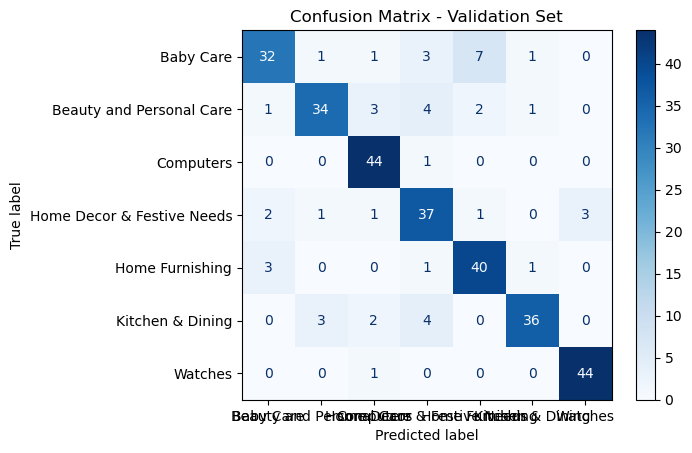

In [31]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Validation Set")
plt.show()

# Results comparison

``First test : 3 epochs - learning rate=5e-5``

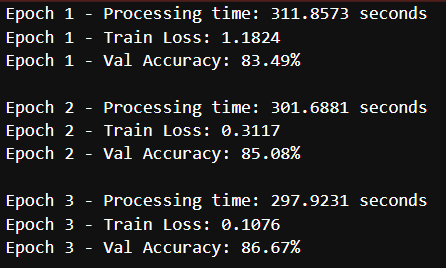

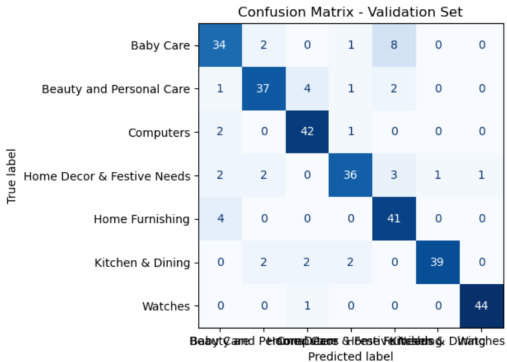

=> The Train Loss decreases rapidly

``Second test : 6 epochs - learning rate=1e-5``

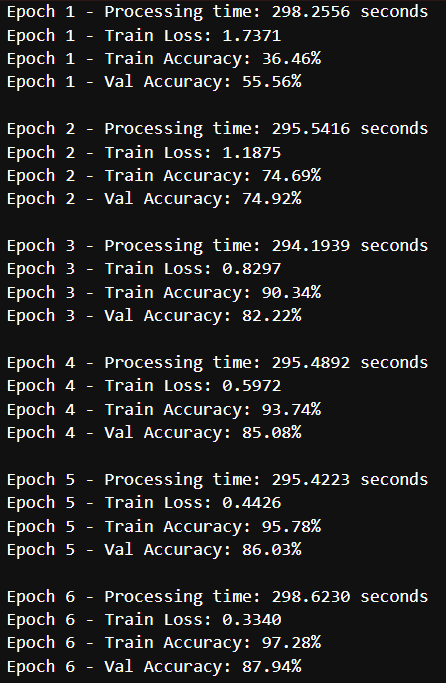

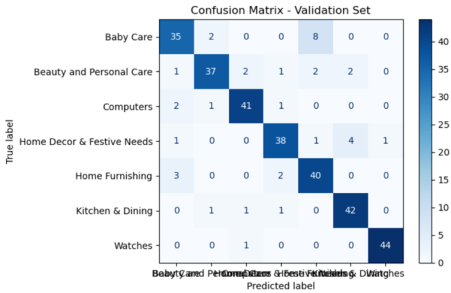

=> Good performances but the model overfits. rem : After 6 epochs the processing time becomes very long

``Third test : 8 epochs - Data Augmentation - learning rate=1e-5``

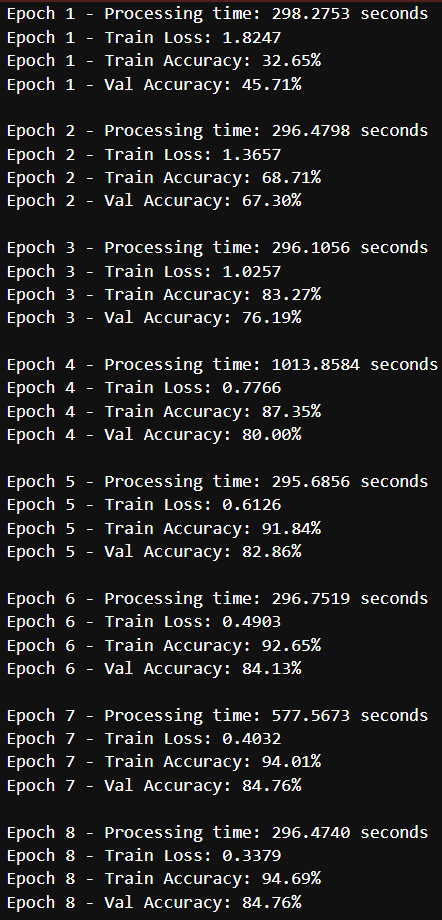

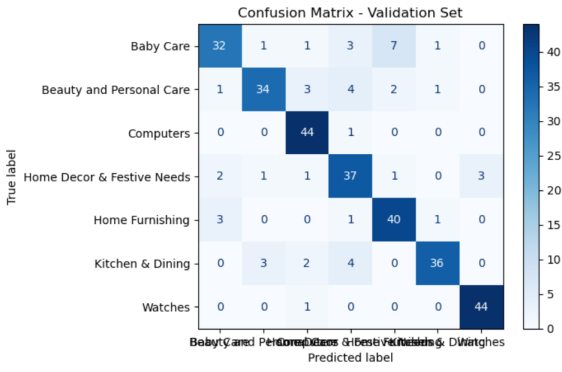